In [ ]:
# Import libraries

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# don't truncate columns in pandas
pd.set_option('display.max_colwidth', None)
pd.options.display.max_rows = 300

In [ ]:
# Define functions for data processing
def get_date(url):
    # GEDI02_A_2019262193446_O04362_01_T00992_02_003_01_V002_subsetted.h5 represents day 262 of 2019
    date_str = url.split('_')[2]
    year = int(date_str[:4]) 
    day = int(date_str[4:7]) 

    date = datetime(year, 1, 1) + timedelta(days = day - 1)
    return date.strftime('%Y-%m-%d')

def label_raster_val(value):
    # Handle NaN values
    if pd.isna(value):
        return 'Unknown'
    
    # Convert to int to handle float values like 7.0
    value = int(value)
    
    # Deforestation years
    if 0 <= value <= 24:
        return f'deforestation_{2000 + value}'
    
    # Residual years (forgotten to be marked as deforestation)
    elif 50 <= value <= 64:
        return f'residual_{2010 + (value - 50)}'
    
    # Special categories
    elif value == 91:
        return 'Hidrografia'
    elif value == 100:
        return 'Vegetacao Nativa'
    elif value == 101:
        return 'Nao Floresta'
    
    # Unknown
    else:
        return 'Unknown'

In [32]:
# Get the CSV from link - Process entire file in chunks
path = '../csv_files/gedi_prodes_joined_1.csv'

chunk_size = 100000  # Process 100k rows at a time
chunks = []

print("Reading file in chunks...")
for i, chunk in enumerate(pd.read_csv(path, chunksize=chunk_size)):
    # Apply transformations to each chunk using defined functions
    chunk['date'] = chunk['source_url'].apply(get_date)
    chunk['land_class'] = chunk['RASTERVALU'].apply(label_raster_val)
    
    # Remove rows marked as deforestation_2007
    chunk = chunk[chunk['land_class'] != 'deforestation_2007']
    
    chunks.append(chunk)
    print(f"  Processed chunk {i+1} ({len(chunk)} rows)")

# Combine all chunks
df = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")
print(df.iloc[0])

Reading file in chunks...
  Processed chunk 1 (78977 rows)
  Processed chunk 2 (98894 rows)
  Processed chunk 3 (91915 rows)
  Processed chunk 4 (65069 rows)
  Processed chunk 5 (93483 rows)
  Processed chunk 6 (100000 rows)
  Processed chunk 7 (92548 rows)
  Processed chunk 8 (63554 rows)
  Processed chunk 9 (95424 rows)
  Processed chunk 10 (98503 rows)
  Processed chunk 11 (100000 rows)
  Processed chunk 12 (79318 rows)
  Processed chunk 13 (86199 rows)
  Processed chunk 14 (98622 rows)
  Processed chunk 15 (99090 rows)
  Processed chunk 16 (100000 rows)
  Processed chunk 17 (71109 rows)
  Processed chunk 18 (93743 rows)
  Processed chunk 19 (99453 rows)
  Processed chunk 20 (99459 rows)
  Processed chunk 21 (99998 rows)
  Processed chunk 22 (76760 rows)
  Processed chunk 23 (89830 rows)
  Processed chunk 24 (99644 rows)
  Processed chunk 25 (95516 rows)
  Processed chunk 26 (99735 rows)
  Processed chunk 27 (95957 rows)
  Processed chunk 28 (68202 rows)
  Processed chunk 29 (99740 

In [33]:
# Add temporal columns for analysis
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

print(f"\nUnique land classes found:")
print(df['land_class'].unique())


Unique land classes found:
['Vegetacao Nativa' 'Hidrografia' 'Nao Floresta' 'residual_2010'
 'deforestation_2008' 'deforestation_2010' 'residual_2011'
 'deforestation_2024' 'deforestation_2012' 'deforestation_2014'
 'deforestation_2009' 'residual_2015' 'deforestation_2023' 'residual_2013'
 'deforestation_2019' 'deforestation_2017' 'deforestation_2021'
 'deforestation_2020' 'residual_2024' 'deforestation_2011' 'residual_2019'
 'deforestation_2022' 'deforestation_2016' 'residual_2021'
 'deforestation_2013' 'residual_2014' 'deforestation_2018' 'residual_2016'
 'deforestation_2015' 'residual_2018' 'residual_2017' 'residual_2020'
 'residual_2022' 'residual_2023' 'residual_2012' 'Unknown']


In [34]:
# Print land class distribution
print("\n=== LAND CLASS DISTRIBUTION ===")
land_class_counts = df['land_class'].value_counts()
print(land_class_counts)

print(f"\nTotal rows: {len(df):,}")


=== LAND CLASS DISTRIBUTION ===
land_class
Vegetacao Nativa      27415796
Nao Floresta           1296298
Hidrografia             191566
deforestation_2022      140634
deforestation_2021      138329
deforestation_2020      107333
deforestation_2008      100254
deforestation_2023       86975
deforestation_2019       83427
deforestation_2024       65360
deforestation_2009       64762
deforestation_2010       63662
deforestation_2018       49179
deforestation_2016       47988
deforestation_2011       47234
deforestation_2017       45303
deforestation_2015       38748
deforestation_2013       37617
deforestation_2014       30965
deforestation_2012       28684
residual_2015            11581
residual_2019             3884
residual_2024             3411
residual_2010             2249
Unknown                   2106
residual_2016             1708
residual_2023              897
residual_2011              844
residual_2013              780
residual_2020              758
residual_2018             

In [35]:
# Get the number of negative rh values

total_deforested_rows = len(df[df['land_class'].str.startswith('deforestation_')])
print("Total rows marked as deforested: ", total_deforested_rows)

overall_negative_rh_count = len(df[
    (df['rh25'] < 0) |
    (df['rh50'] < 0) |
    (df['rh75'] < 0) |
    (df['rh95'] < 0)
])

rh95_negative_count = len(df[df['rh95'] < 0])
rh_75_negative_count = len(df[df['rh75'] < 0])
rh50_negative_count = len(df[df['rh50'] < 0])
rh25_negative_count = len(df[df['rh25'] < 0])

print("OVERALL total rows with negative RH values: ", overall_negative_rh_count)
print("# rows with negative RH95 values: ", rh95_negative_count)
print("# rows with negative RH75 values: ", rh_75_negative_count)
print("# rows with negative RH50 values: ", rh50_negative_count)
print("# rows with negative RH25 values: ", rh25_negative_count)


deforestation_negative_rh_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (
        (df['rh25'] < 0) |
        (df['rh50'] < 0) |
        (df['rh75'] < 0) |
        (df['rh95'] < 0)
    )
])

deforested_rh95_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh95'] < 0)
])
deforested_rh75_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh75'] < 0)
])
deforested_rh50_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh50'] < 0)
])
deforested_rh25_negative_count = len(df[
    (df['land_class'].str.startswith('deforestation_')) & 
    (df['rh25'] < 0)
])

print("OVERALL rows marked as deforested with negative RH values: ", deforestation_negative_rh_count)
print("# rows marked as deforested with negative RH95 values: ", deforested_rh95_negative_count)
print("# rows marked as deforested with negative RH75 values: ", deforested_rh75_negative_count)
print("# rows marked as deforested with negative RH50 values: ", deforested_rh50_negative_count)
print("# rows marked as deforested with negative RH25 values: ", deforested_rh25_negative_count)

Total rows marked as deforested:  1176454
OVERALL total rows with negative RH values:  3985951
# rows with negative RH95 values:  0
# rows with negative RH75 values:  102
# rows with negative RH50 values:  506128
# rows with negative RH25 values:  3985951
OVERALL rows marked as deforested with negative RH values:  489399
# rows marked as deforested with negative RH95 values:  0
# rows marked as deforested with negative RH75 values:  9
# rows marked as deforested with negative RH50 values:  77341
# rows marked as deforested with negative RH25 values:  489399


In [36]:
# Get statistics for the rows with negative deforestation values
only_negative_rh_deforested = df[
    (df['land_class'].str.startswith('deforestation_')) &
    (df['rh25'] < 0)
    ]

print(len(only_negative_rh_deforested))
avg_rh25_neg_rh_deforested = only_negative_rh_deforested['rh25'].mean()
avg_rh50_neg_rh_deforested = only_negative_rh_deforested['rh50'].mean()
avg_rh75_neg_rh_deforested = only_negative_rh_deforested['rh75'].mean()
avg_rh95_neg_rh_deforested = only_negative_rh_deforested['rh95'].mean()

print(f"Average rh25 values for deforested points with negative rh: {avg_rh25_neg_rh_deforested}")
print(f"Average rh50 values for deforested points with negative rh: {avg_rh50_neg_rh_deforested}")
print(f"Average rh75 values for deforested points with negative rh: {avg_rh75_neg_rh_deforested}")
print(f"Average rh95 values for deforested points with negative rh: {avg_rh95_neg_rh_deforested}")


489399
Average rh25 values for deforested points with negative rh: -1.3419148179706126
Average rh50 values for deforested points with negative rh: 0.7825477166892455
Average rh75 values for deforested points with negative rh: 3.9704283008342895
Average rh95 values for deforested points with negative rh: 10.462765820935473


## Data Visualization

Create histograms and charts from the complete dataset.

C:\Users\akhand04\AppData\Local\Temp\2\ipykernel_15248\3250762138.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=metrics)


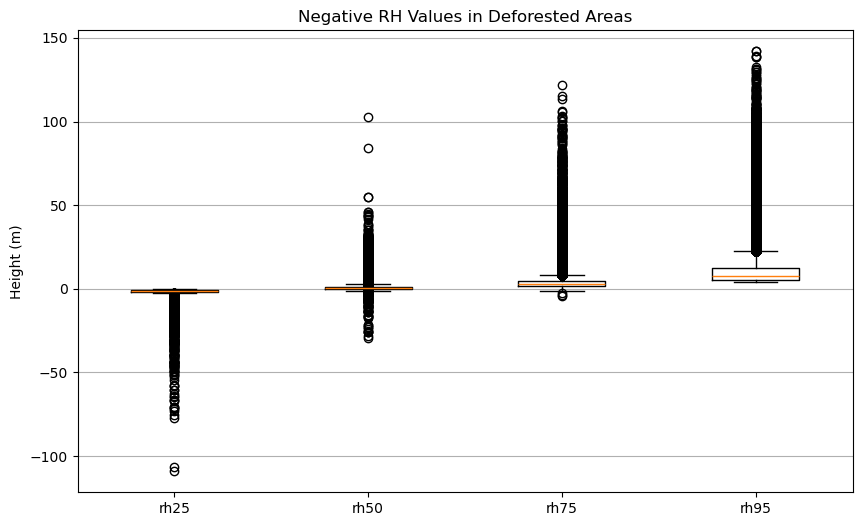


5-Number Summary:
       rh25    rh50    rh75    rh95
min -109.12  -29.58   -4.52    4.00
25%   -1.64    0.07    1.79    5.24
50%   -1.19    0.41    2.58    7.41
75%   -0.86    1.16    4.42   12.23
max   -0.03  102.77  121.67  142.02


In [37]:
#Boxplots for the negative rh values in deforested points

metrics = ['rh25', 'rh50', 'rh75', 'rh95']
data = [only_negative_rh_deforested[m] for m in metrics]

plt.figure(figsize=(10,6))
plt.boxplot(data, labels=metrics)
plt.ylabel('Height (m)')
plt.title('Negative RH Values in Deforested Areas')
plt.grid(axis='y')
plt.show()

print("\n5-Number Summary:")
print(only_negative_rh_deforested[metrics].describe().loc[['min', '25%', '50%', '75%', 'max']])


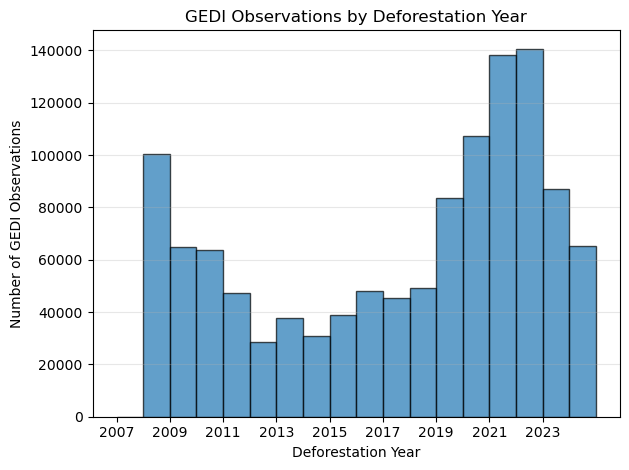


Deforestation observations: 1176454
Year range: 2008 - 2024


In [38]:

deforestation_data = df[df['land_class'].str.startswith('deforestation_', na=False)]
deforestation_years = deforestation_data['land_class'].str.replace('deforestation_', '').astype(int)

plt.hist(deforestation_years, bins=range(2007, 2026), edgecolor='black', alpha=0.7)
plt.xlabel('Deforestation Year')
plt.ylabel('Number of GEDI Observations')
plt.title('GEDI Observations by Deforestation Year')
plt.xticks(range(2007, 2025, 2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDeforestation observations: {len(deforestation_data)}")
print(f"Year range: {deforestation_years.min()} - {deforestation_years.max()}")

In [39]:
deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)
deforestation_df['years_since_deforestation'] = deforestation_df['year'] - deforestation_df['deforestation_year']
deforestation_df = deforestation_df[deforestation_df['years_since_deforestation'] >= 0]

print("Total rows before removing negative RH values: ", len(deforestation_df))

# Remove rows with negative RH values
deforestation_df = deforestation_df[
    (deforestation_df['rh25'] >= 0) & 
    (deforestation_df['rh50'] >= 0) & 
    (deforestation_df['rh75'] >= 0) & 
    (deforestation_df['rh95'] >= 0)
]

print("Total rows after removing negative RH values: ", len(deforestation_df))

regrowth_stats = deforestation_df.groupby('years_since_deforestation')[['rh25', 'rh50', 'rh75', 'rh95']].agg(['mean'])

Total rows before removing negative RH values:  759266
Total rows after removing negative RH values:  364146


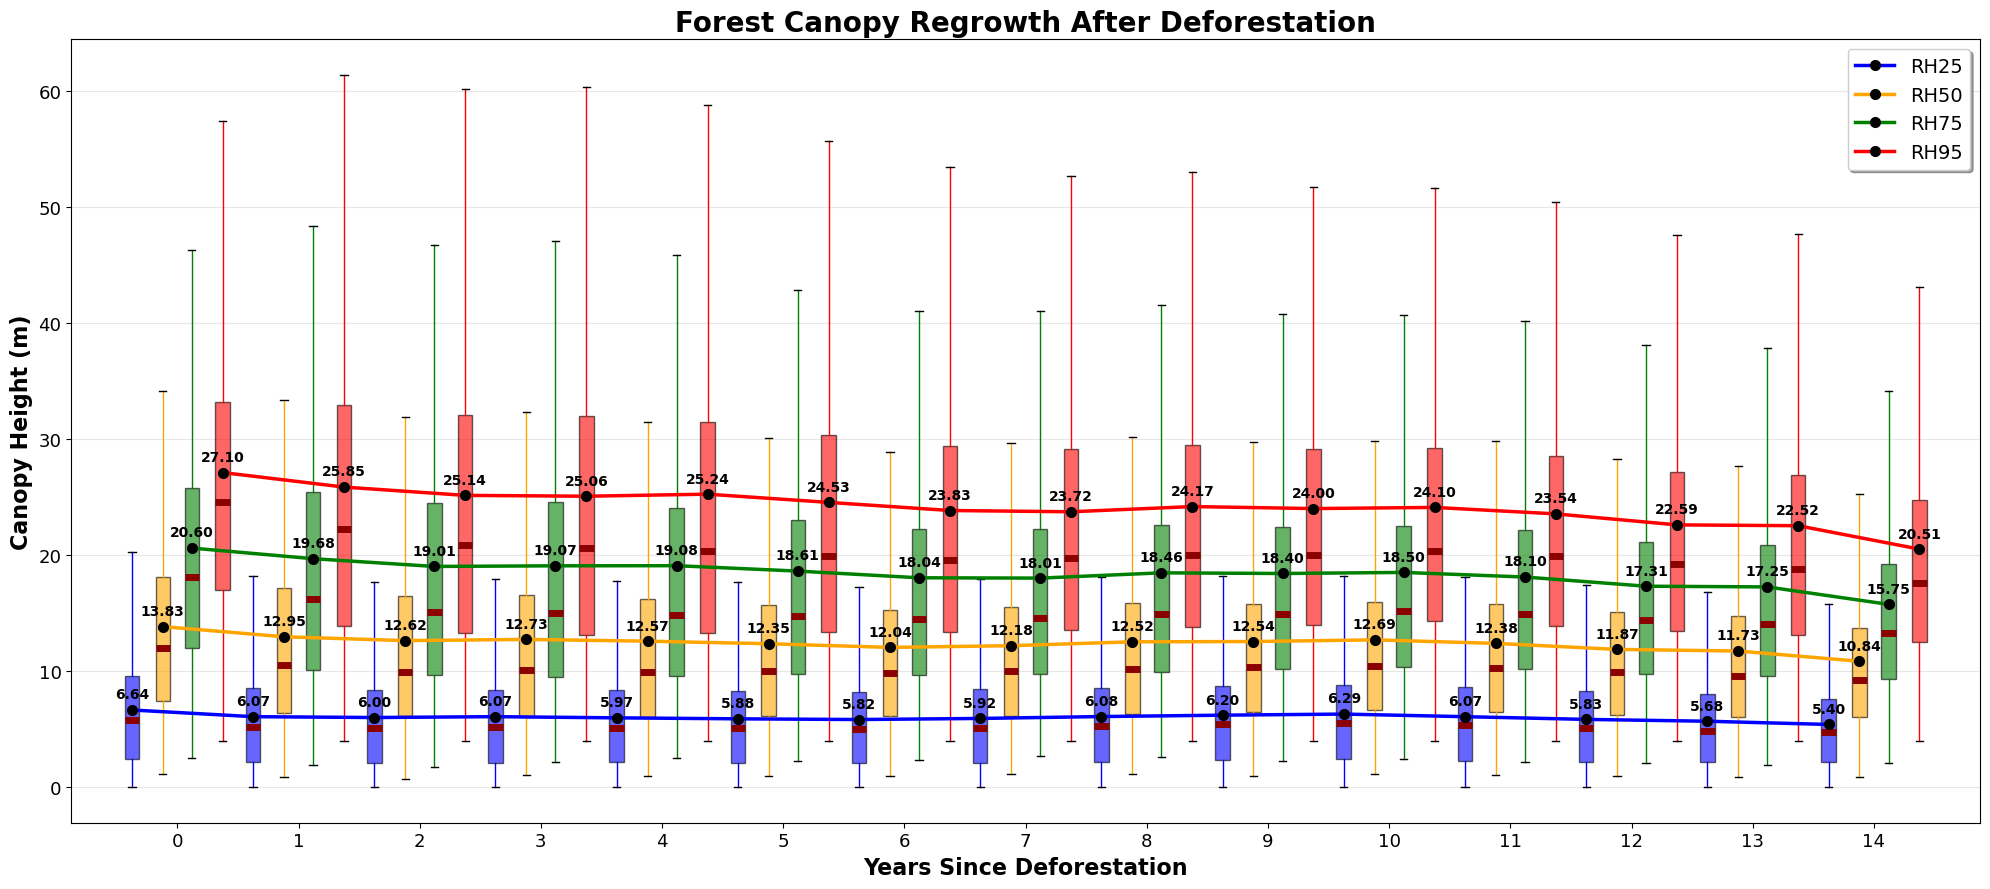

In [40]:
# Show all charts combined with boxplots side by side
fig, ax = plt.subplots(figsize=(20, 9))
years_list = sorted(deforestation_df['years_since_deforestation'].unique())


width = 0.15
offsets = [-2.5*width, -0.8*width, 0.8*width, 2.5*width]

for i, (metric, color, label, offset) in enumerate(zip(metrics, colors, ['RH25', 'RH50', 'RH75', 'RH95'], offsets)):
    data_by_year = [deforestation_df[deforestation_df['years_since_deforestation'] == year][metric].dropna() 
                    for year in years_list]
    
    # Position boxplots with offset
    positions = [year + offset for year in years_list]
    
    # Create boxplot
    bp = ax.boxplot(data_by_year, positions=positions, widths=width*0.8, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='darkred', linewidth=5),
                    whiskerprops=dict(color=color),
                    showfliers=False)
    
    # Overlay line connecting means
    means = regrowth_stats[metric]['mean']
    ax.plot(positions, means, marker='o', color=color, markerfacecolor='black', markeredgecolor='black', 
            linewidth=2.5, markersize=7, zorder=3, label=label)

    # Label each point with its value
    for x, y in zip(positions, means):
        ax.text(x, y + 1, f'{y:.2f}', fontsize=10, ha='center', color='black', fontweight='bold')

ax.set_xlabel('Years Since Deforestation', fontsize=16, fontweight='bold')
ax.set_ylabel('Canopy Height (m)', fontsize=16, fontweight='bold')
ax.set_title('Forest Canopy Regrowth After Deforestation', fontsize=20, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(years_list)
ax.set_xticklabels([int(year) for year in years_list], fontsize=13)
ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()

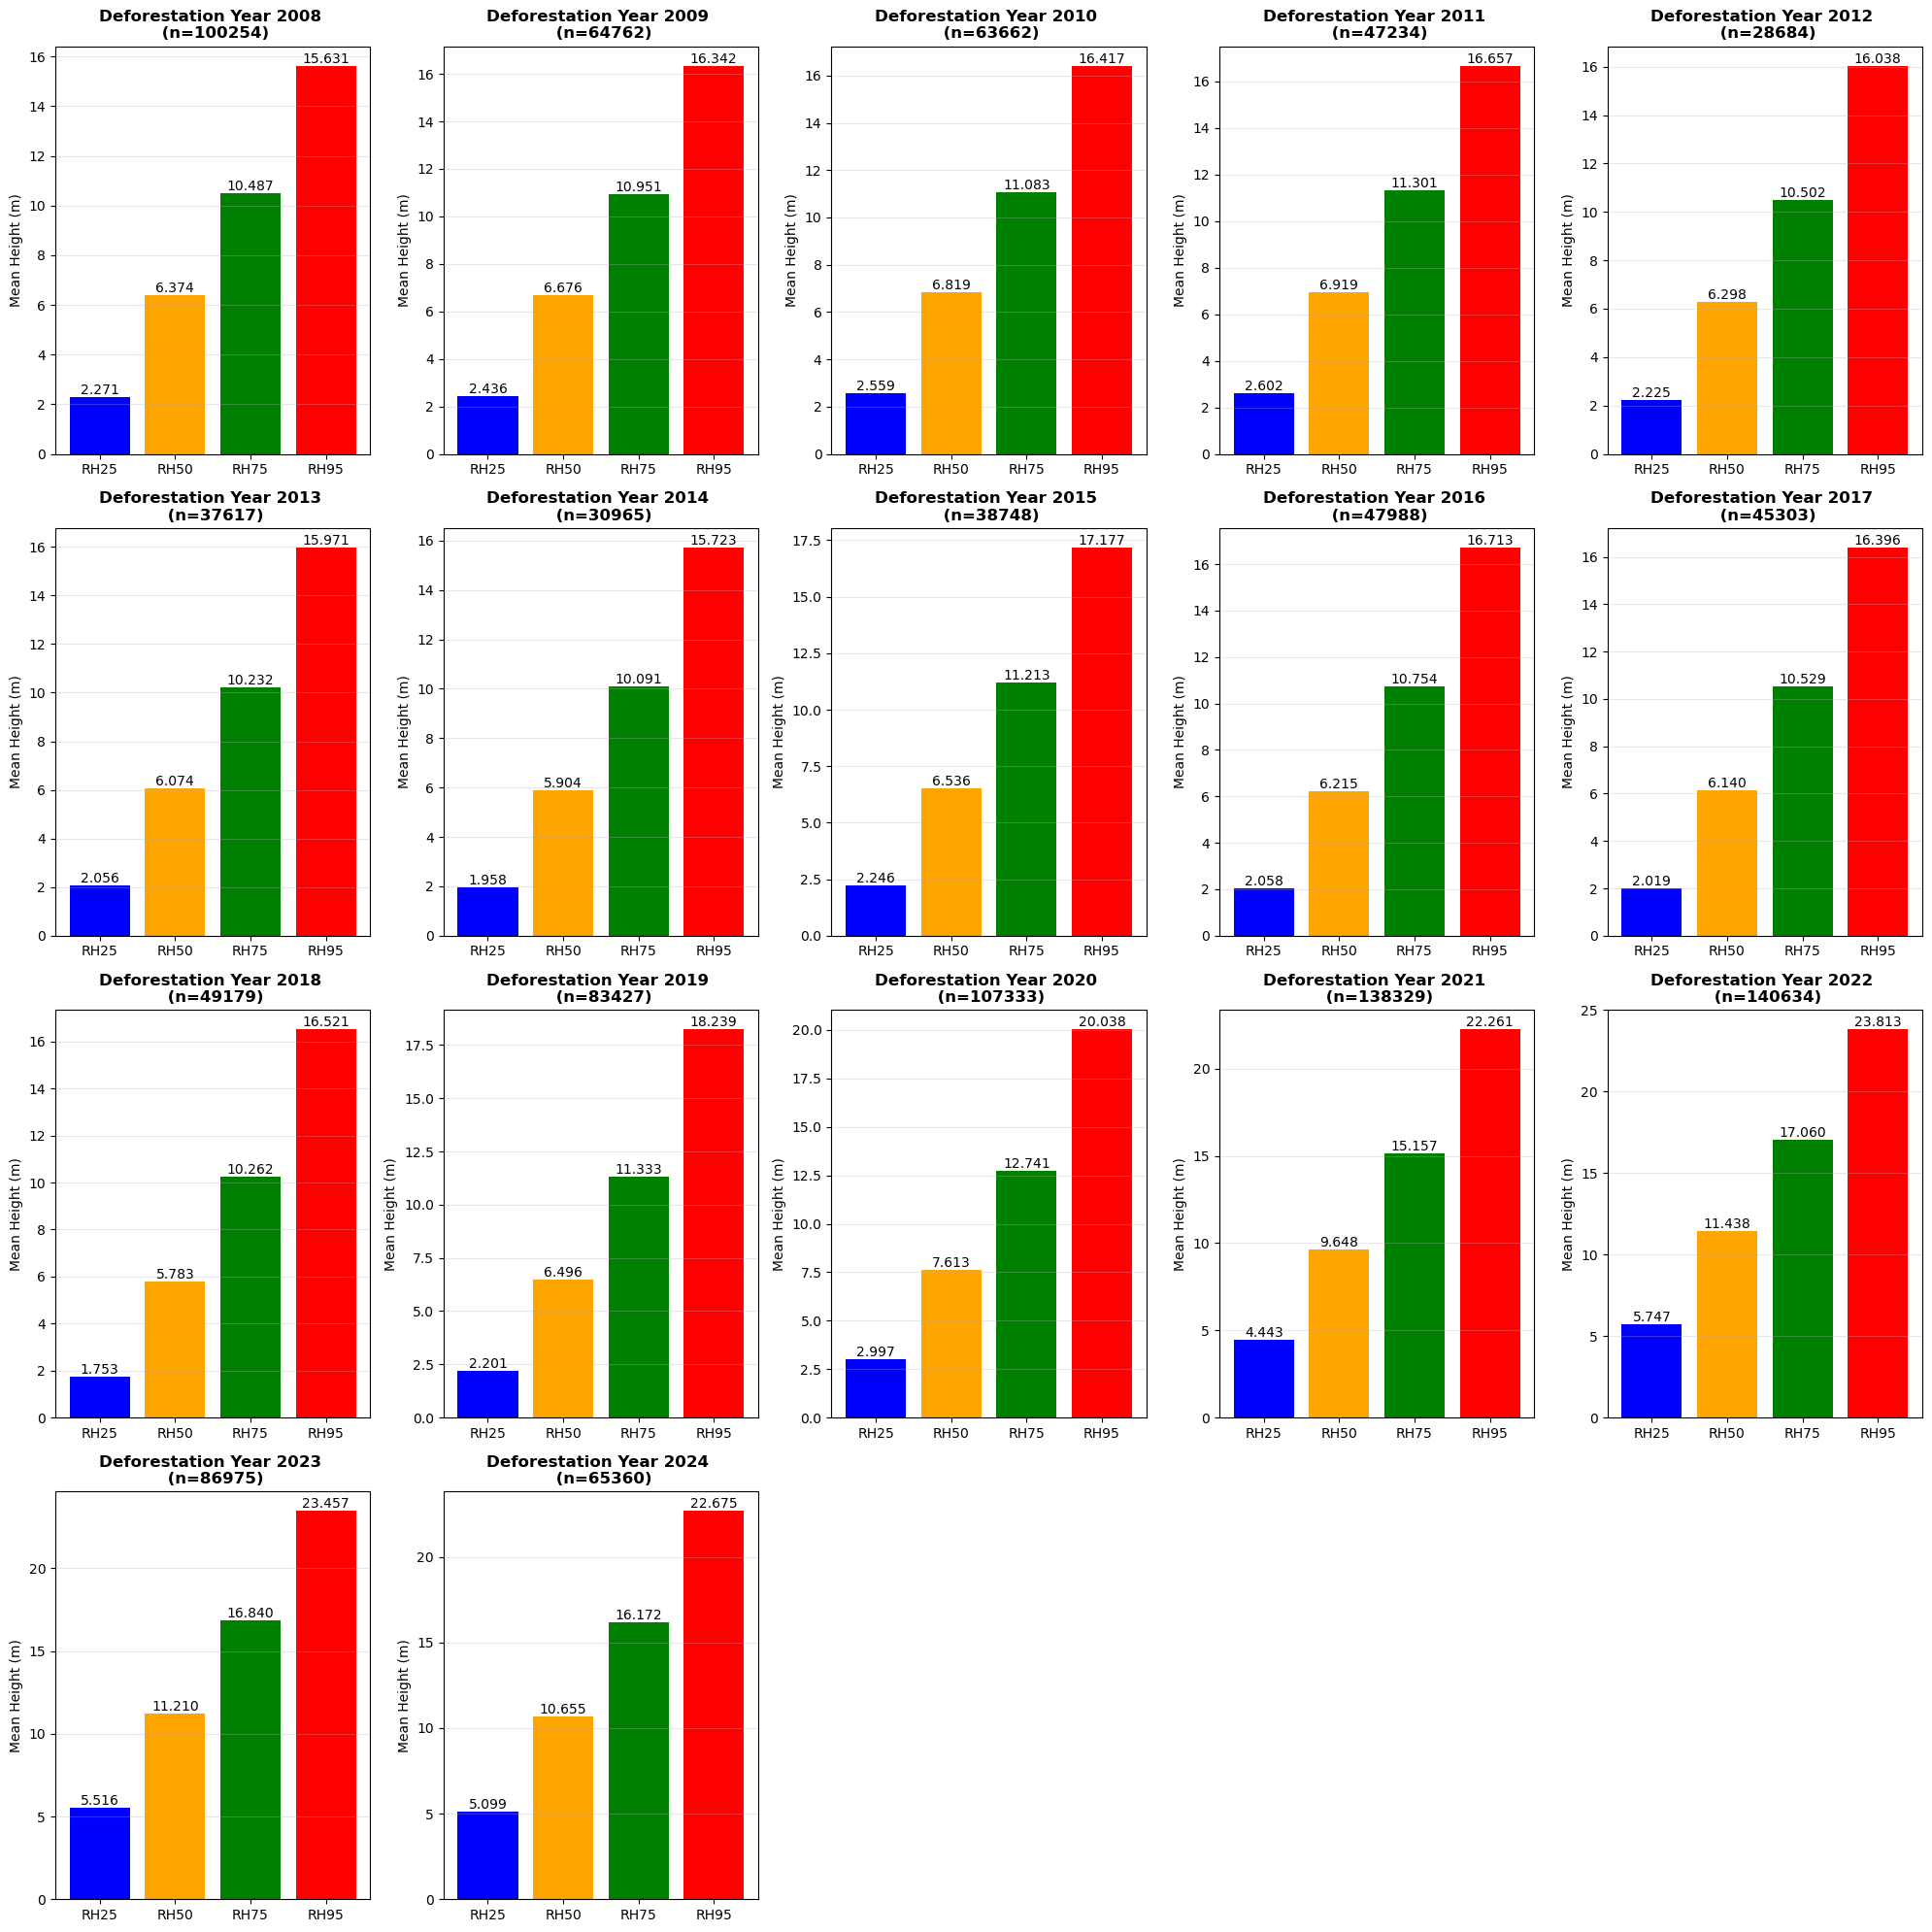

In [41]:
# Bar charts for each deforestation year showing all 4 rh metrics

deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)

years = sorted(deforestation_df['deforestation_year'].unique())
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

# rows/columns needed for subplots
n_years = len(years)
n_cols = 5
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    
    # Calc mean heights for each rh value
    mean_heights = [year_data[metric].mean() for metric in metrics]
    
    # Create bar chart
    bars = ax.bar(['RH25', 'RH50', 'RH75', 'RH95'], mean_heights, 
                   color=['blue', 'orange', 'green', 'red'])
    
    ax.set_ylabel('Mean Height (m)')
    ax.set_title(f'Deforestation Year {year} \n (n={len(year_data)})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # label bars with values
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')


# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout() 
plt.show()

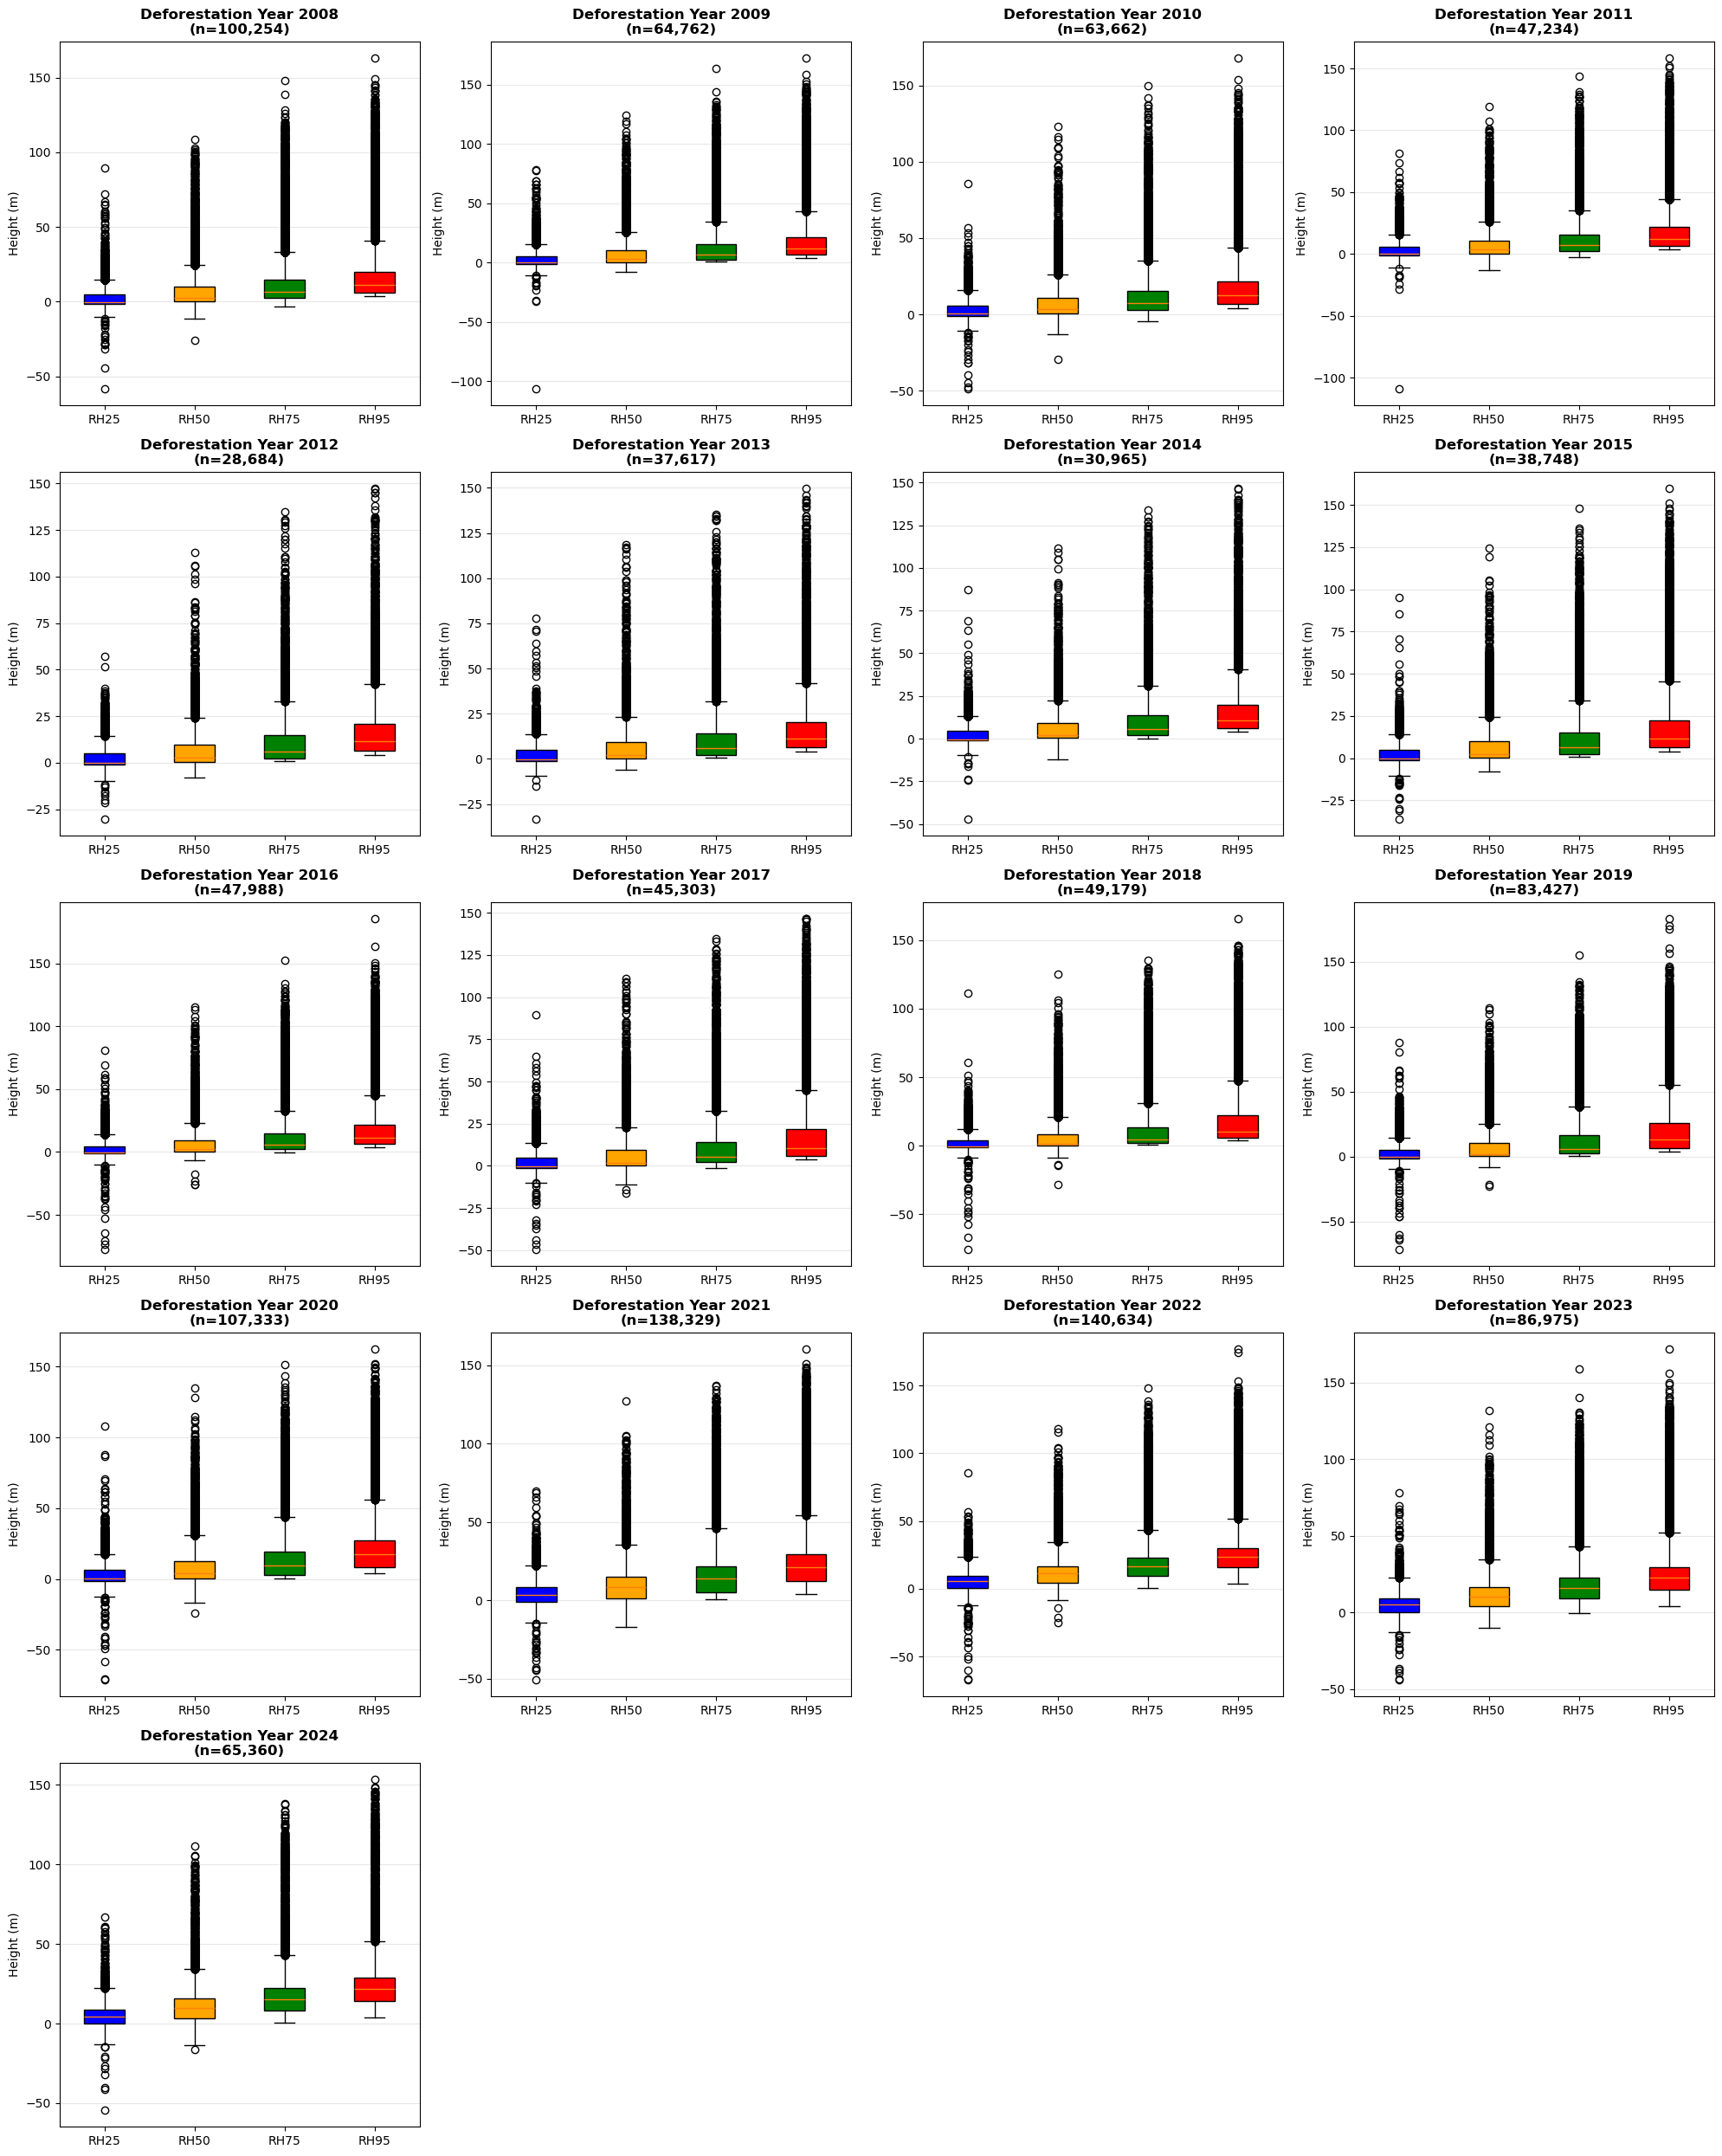


=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR ===

Deforestation Year 2008 (n=100,254):
      rh25    rh50    rh75    rh95
min -58.34  -25.65   -3.48    4.00
25%  -1.23    0.33    2.39    6.36
50%  -0.07    2.80    6.39   11.26
75%   5.14    9.98   14.67   20.26
max  89.69  108.88  148.29  163.20 


Deforestation Year 2009 (n=64,762):
       rh25    rh50    rh75    rh95
min -106.48   -7.49    0.74    4.00
25%   -1.19    0.37    2.47    6.58
50%    0.11    3.14    6.89   11.98
75%    5.37   10.41   15.36   21.30
max   78.63  124.39  163.30  172.52 


Deforestation Year 2010 (n=63,662):
      rh25    rh50    rh75    rh95
min -48.95  -29.58   -4.52    4.00
25%  -1.19    0.41    2.58    6.69
50%   0.29    3.48    7.25   12.24
75%   5.69   10.71   15.59   21.50
max  85.76  123.39  149.78  168.25 


Deforestation Year 2011 (n=47,234):
       rh25    rh50    rh75    rh95
min -109.12  -13.33   -2.62    4.00
25%   -1.19    0.41    2.54    6.59
50%    0.29    3.51    7.28   12.21
75%    5.65   10.

In [42]:
# Boxplots for each deforestation year showing all 4 rh metrics

deforestation_df = df[df['land_class'].str.startswith('deforestation_')].copy()
deforestation_df['deforestation_year'] = deforestation_df['land_class'].str.replace('deforestation_','').astype(int)

years = sorted(deforestation_df['deforestation_year'].unique())
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

# rows/columns needed for subplots
n_years = len(years)
n_cols = 4
n_rows = (n_years + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Flatten to 1D array

for idx, year in enumerate(years):
    ax = axes[idx]
    
    # Get data for this year
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    
    data_by_metric = [year_data[metric] for metric in metrics]
    
    # create boxplot
    bp = ax.boxplot(data_by_metric, tick_labels=['RH25', 'RH50', 'RH75', 'RH95'], patch_artist=True)
    
    # color boxes
    colors = ['blue', 'orange', 'green', 'red']
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
    
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Deforestation Year {year}\n(n={len(year_data):,})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# remove unused plots
for j in range(len(years), n_cols*n_rows):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("\n=== 5-NUMBER SUMMARY BY DEFORESTATION YEAR ===\n")
for year in years:
    year_data = deforestation_df[deforestation_df['deforestation_year'] == year]
    print(f"Deforestation Year {year} (n={len(year_data):,}):")
    summary = year_data[metrics].describe().loc[['min', '25%', '50%', '75%', 'max']]
    print(summary.round(2), '\n\n')



Mean canopy heights by years since deforestation:
years_since_deforestation
0     13.83
1     12.95
2     12.62
3     12.73
4     12.57
5     12.35
6     12.04
7     12.18
8     12.52
9     12.54
10    12.69
11    12.38
12    11.87
13    11.73
14    10.84
Name: mean, dtype: float64


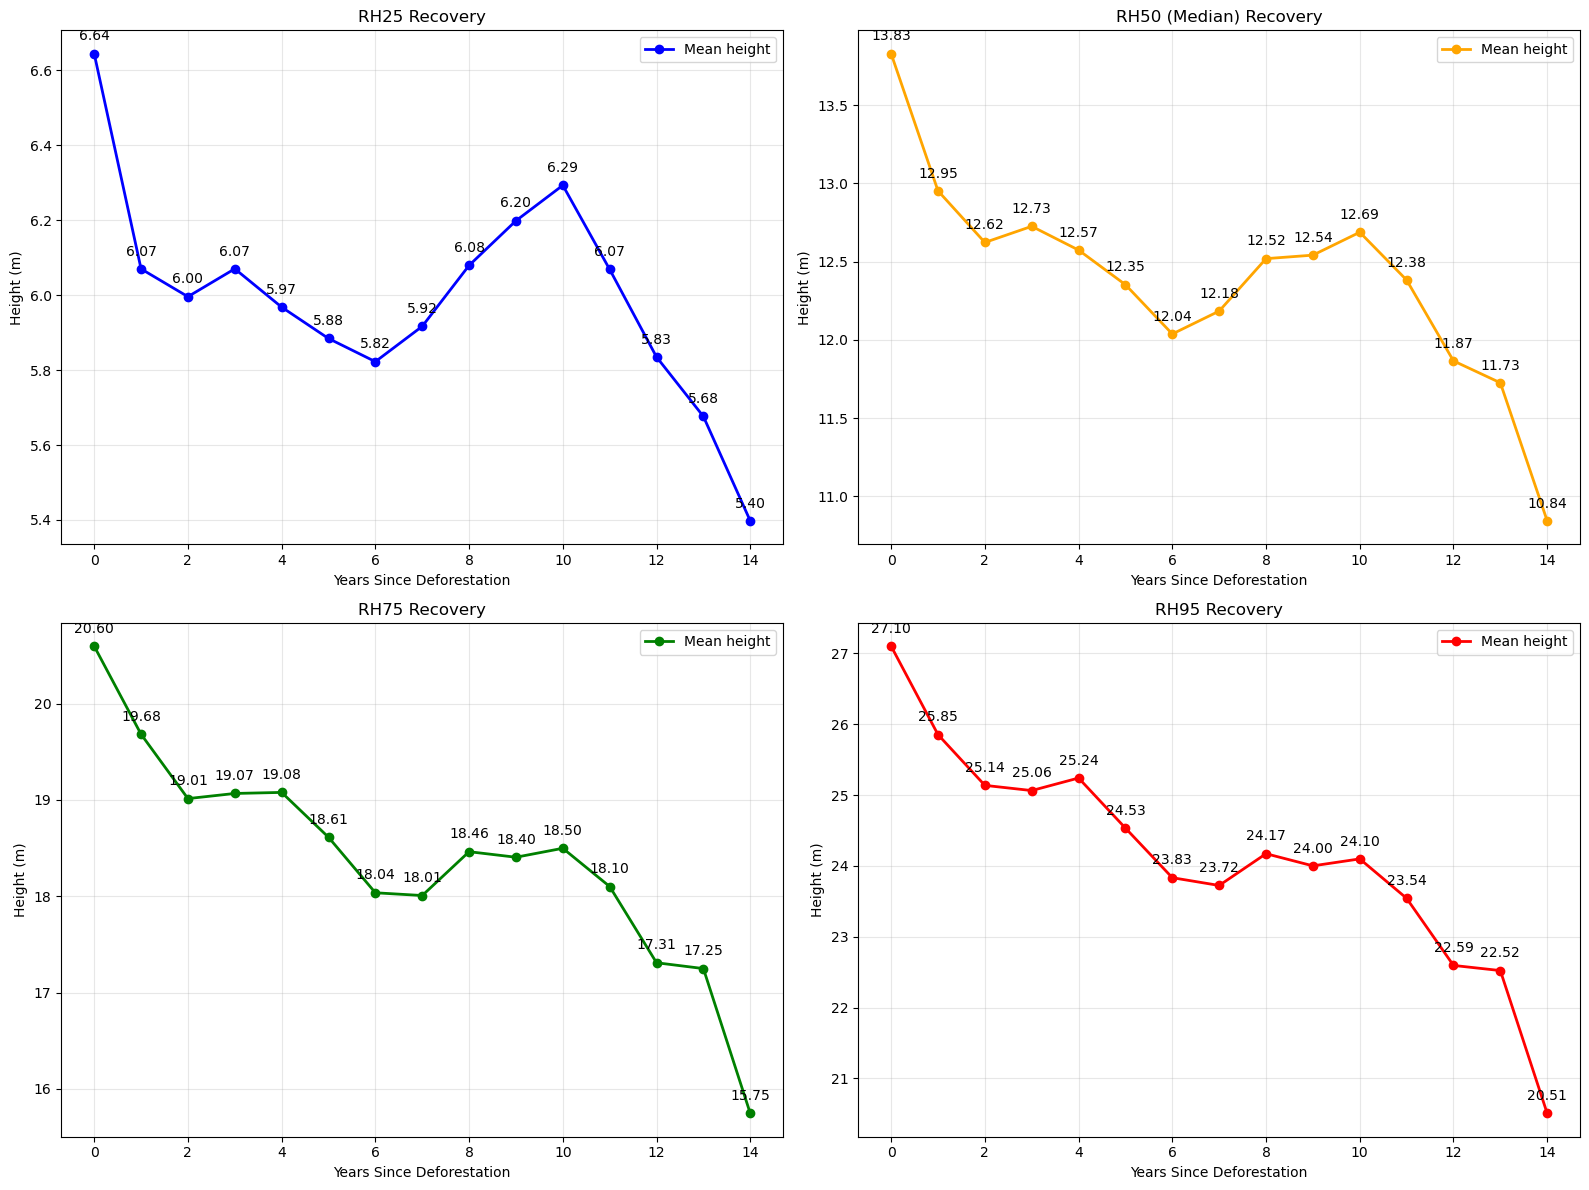

In [43]:
print("\nMean canopy heights by years since deforestation:")
print(regrowth_stats['rh50']['mean'].round(2))

# Visualization: Height recovery over time (simple line plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['rh25', 'rh50', 'rh75', 'rh95']
titles = ['RH25 Recovery', 'RH50 (Median) Recovery', 'RH75 Recovery', 'RH95 Recovery']
colors = ['blue', 'orange', 'green', 'red']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    
    years = regrowth_stats.index
    means = regrowth_stats[metric]['mean']
    
    # plot mean
    ax.plot(years, means, marker='o', linewidth=2, color=color, label='Mean height')
    
    ax.set_xlabel('Years Since Deforestation')
    ax.set_ylabel('Height (m)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    #label each point with its value
    for x, y in zip(years, means):
        y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
        ax.text(x, y + y_offset, f'{y:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [44]:
# IGNORE - AI GENERATED FOR TESTING

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# metrics = ['rh25', 'rh50', 'rh75', 'rh95']
# titles = ['RH25 (25th percentile height)', 'RH50 (Median height)', 
#           'RH75 (75th percentile height)', 'RH95 (95th percentile height)']

# for idx, (metric, title) in enumerate(zip(metrics, titles)):
#     ax = axes[idx // 2, idx % 2]
    
#     # Create boxplot for each land class
#     land_classes = df['land_class'].unique()
#     data_by_class = [df[df['land_class'] == lc][metric].dropna() for lc in land_classes]
    
#     ax.boxplot(data_by_class, tick_labels=land_classes)
#     ax.set_ylabel('Height (m)')
#     ax.set_title(title)
#     ax.tick_params(axis='x', rotation=45)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Summary statistics
# print("\nCanopy Height Summary by Land Class:")
# print(df.groupby('land_class')[metrics].mean().round(2))